**Previously on:** Lecture 19 fit a line to the steels data and, before plotting anything, quietly
dropped row 626 because its tensile strength (6661 MPa) was almost certainly a typo -- the
next-highest value in all 915 alloys was under 900 MPa. We promised then that Lecture 27 would
teach you to catch things like that systematically. This is that lecture.

Today's topics:
* the z-score rule and the IQR rule -- two quantitative screens built from Module 1 statistics
* visual detection: box plots (`plt.boxplot`, new today) and residual plots (Lecture 19/20's
  fitting, read a different way)
* the judgment call: honest cleanup versus data-doctoring

> By the end of today you should be able to complete Problems 1-3 of Homework 9: flag and justify
> the removal (or retention) of anomalous points in a messy dataset, using a quantitative rule and
> your own judgment.

# Why outliers matter for modeling

You already know how to *fit* a model. Today is about deciding **which points get to vote**. A
single bad point can tilt an entire regression line -- 15 clean synthetic points, one planted bad
one:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(219)
x_demo = np.linspace(0, 10, 15)
y_demo = 2.0 * x_demo + 5 + rng.normal(0, 1.5, size=15)
x_bad = np.append(x_demo, 9.5)
y_bad = np.append(y_demo, 55)  # one planted bad point, way off the trend

m_clean, b_clean = np.polyfit(x_demo, y_demo, 1)
m_bad, b_bad = np.polyfit(x_bad, y_bad, 1)
print(f'slope without the bad point: {m_clean:.2f}')
print(f'slope with the bad point:    {m_bad:.2f}')

slope without the bad point: 1.95
slope with the bad point:    2.77


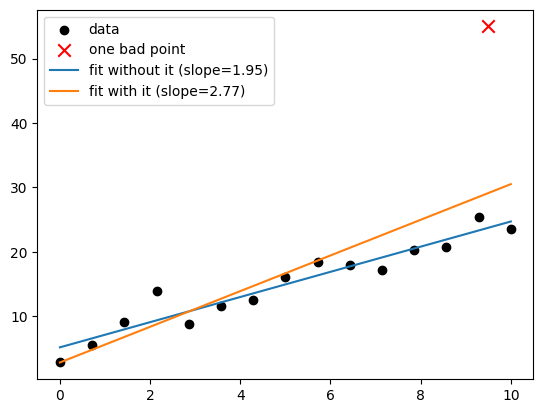

In [2]:
xx = np.linspace(0, 10, 200)
plt.scatter(x_demo, y_demo, color='k', label='data')
plt.scatter([9.5], [55], color='red', marker='x', s=80, label='one bad point')
plt.plot(xx, m_clean * xx + b_clean, color='C0', label=f'fit without it (slope={m_clean:.2f})')
plt.plot(xx, m_bad * xx + b_bad, color='C1', label=f'fit with it (slope={m_bad:.2f})')
plt.legend()
plt.show()

One point out of sixteen (6% of the data) dragged the slope from 1.95 to 2.77, a 42% change, and
visibly tilted the line away from the other fifteen points it's supposed to describe. That's
today's whole motivation in one picture.

Define **outlier** informally: a point unusually far from the rest of the data, *in the context of
the question you're asking*. Preview the day's tension up front: "unusual" is not the same as
"wrong." We'll build two quantitative screens (z-score, IQR), then spend real time on the judgment
call -- Homework 9 will ask you to defend your removals in words, not just code.

# The z-score rule

## Dataset: Metal Alloy Elemental Properties (uncleaned)

In [3]:
import os
import pandas as pd

_file = 'alloy_cleaning.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github, encoding='latin1')
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data.head()

,number,name,symbol,name_symbol,pronunciation,appearance,atomic_number,group_block,period,element_category,...,band_gap,recognised_as_an_element_by,curie_point,recognized_as_a_unique_metal_by,recognized_as_a_distinct_element_by,thermal_diffusivity,tensile_strength,molar_volume,proposed_formal_name,alternative_names
0,1,Hydrogen,H,"hydrogen, H","/?ha?dr?d??n/, HY-dr?-j?n",colorless gas,1,"group 1, s-block",1,diatomic nonmetal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Helium,He,"helium, He","/?hi?li?m/, HEE-lee-?m","colorless gas, exhibiting a red-orange glow wh...",2,"group 18 (noble gases), s-block",1,noble gas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Lithium,Li,"lithium, Li","/?l??i?m/, LI-thee-?m",silvery-white,3,"group 1 (alkali metals), s-block",2,alkali metal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Beryllium,Be,"beryllium, Be","/b??r?li?m/, b?-RIL-ee-?m",white-gray metallic,4,"group 2 (alkaline earth metals), s-block",2,alkaline earth metal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Boron,B,"boron, B",/?b??r?n/,black-brown,5,"group 13, p-block",2,metalloid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Why this one?

This table (117 elements, 73 scraped-from-the-web columns) is **intentionally left
messy** — do not clean it here. It's the running example for "what does bad data
actually look like": some numeric-looking columns store values as text with embedded
units (e.g. `"(H2) 0.904 kJ/mol"` mixed in with a bare `0.0829`), some property is split
across two near-duplicate columns from British vs. American spelling
(`heat_of_vaporization` vs. `heat_of_vaporisation`) that are almost never both filled
for the same row, and most columns are mostly empty. The point of looking at it here is
to *see* those problems before students are asked to write cleaning code for them.

In [4]:
print(f'{data.shape[0]} rows, {data.shape[1]} columns')
print(data.isna().mean().sort_values(ascending=False).head(10), '\n... (fraction missing, worst 10 columns)')

117 rows, 73 columns
molar_volume                           0.991453
recognized_as_a_unique_metal_by        0.991453
curie_point                            0.991453
recognised_as_an_element_by            0.991453
color                                  0.982906
density_when_liquid_at_mp              0.982906
tensile_strength                       0.982906
thermal_diffusivity                    0.982906
recognized_as_a_distinct_element_by    0.982906
band_gap                               0.982906
dtype: float64 
... (fraction missing, worst 10 columns)


In [5]:
# the same physical quantity split across two differently-spelled columns —
# notice how rarely both are populated for the same element
print(data[['name', 'heat_of_vaporization', 'heat_of_vaporisation']].dropna(how='all').head(8))

        name heat_of_vaporization heat_of_vaporisation
0   Hydrogen    (H2) 0.904 kJ/mol                  NaN
1     Helium               0.0829                  NaN
2    Lithium                  136                  NaN
3  Beryllium                  292                  NaN
4      Boron                  508                  NaN
5     Carbon                  NaN                  NaN
6   Nitrogen                  NaN     (N2) 5.56 kJ/mol
7     Oxygen     (O2) 6.82 kJ/mol                  NaN


In [6]:
# units embedded directly in a column that otherwise looks numeric
print(data['heat_of_vaporization'].dropna().head(8).tolist())

['(H2) 0.904 kJ/mol', '0.0829', '136', '292', '508', '(O2) 6.82 kJ/mol', '6.51', '1.71']


Lecture 4 gave you mean and standard deviation; here's a new quantity built from them: the
**z-score**, `z = (x - mean) / std`, how many standard deviations a point sits from the mean.
`melting_point` is stored as text with missing and annotated entries (`dtype=object`), so step one
is always the same one-liner: coerce to numbers, let anything that fails become `NaN`.

In [7]:
import pandas as pd

mp = pd.to_numeric(data['melting_point'], errors='coerce')
z_mp = (mp - mp.mean()) / mp.std()
data.assign(mp=mp, z_mp=z_mp).dropna(subset=['mp']).sort_values('z_mp')[['name', 'mp', 'z_mp']].head(6)

,name,mp,z_mp
1,Helium,0.95,-1.452026
0,Hydrogen,13.99,-1.436902
9,Neon,24.56,-1.424643
8,Fluorine,53.48,-1.391100
7,Oxygen,54.36,-1.390079
6,Nitrogen,63.15,-1.379884


In [8]:
data.assign(mp=mp, z_mp=z_mp).dropna(subset=['mp']).sort_values('z_mp')[['name', 'mp', 'z_mp']].tail(6)

,name,mp,z_mp
40,Niobium,2750.0,1.736420
41,Molybdenum,2896.0,1.905756
72,Tantalum,3290.0,2.362732
75,Osmium,3306.0,2.381289
74,Rhenium,3459.0,2.558744
73,Tungsten,3695.0,2.832465


Conventional cutoff: flag `abs(z) > 3` (2 and 2.5 are stricter alternatives you'll see elsewhere
-- this is a convention, not a law).

In [9]:
flagged_z = data[z_mp.abs() > 3]
print(f'{len(flagged_z)} elements flagged by |z| > 3 on melting_point')
print(f'largest |z| in the dataset: {z_mp.abs().max():.3f} ({data.loc[z_mp.abs().idxmax(), "name"]})')

0 elements flagged by |z| > 3 on melting_point
largest |z| in the dataset: 2.832 (Tungsten)


Zero. Tungsten, the single highest melting point in the periodic table, sits at z ≈ 2.83 -- close,
but it doesn't clear the fence. That's a deliberately anticlimactic result, and it's the point: the
rule doesn't always find something, and "nothing flagged" is a legitimate answer, not a failure of
the code.

One caveat, stated explicitly: the z-score rule assumes roughly normal, unimodal data. A quick
histogram shows why that matters here:

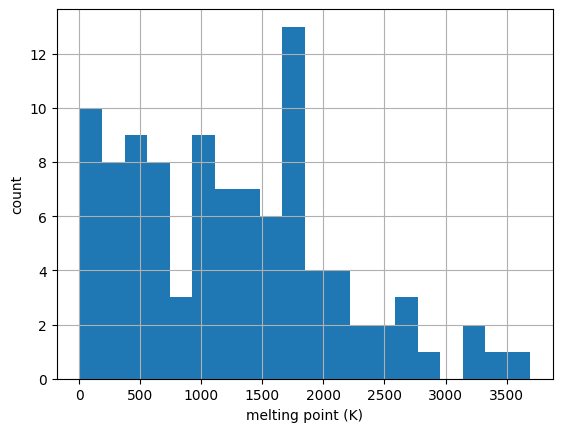

In [10]:
mp.hist(bins=20)
plt.xlabel('melting point (K)')
plt.ylabel('count')
plt.show()

Visibly right-skewed, with a small bunched cluster of very-low-temperature gas elements pulled
away from the main body of solids. Skew can fool the mean and std dev themselves -- a wide std
dev, partly driven by that same skew, is exactly why Tungsten's z-score isn't larger. The ruler is
bent by the thing you're trying to measure with it.

# The IQR rule

Recall percentiles from Lecture 5. Define Q1, Q3, and `IQR = Q3 - Q1`, with the classic fence
`[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`. Like `|z| > 3`, the 1.5 multiplier is a convention, not a law --
Tukey's original choice; Tukey also defined a stricter 3.0x "far out" fence for extreme cases only.

In [11]:
q1, q3 = mp.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f'Q1={q1:.0f} K, Q3={q3:.0f} K, IQR={iqr:.0f} K')
print(f'fence: [{lo:.0f}, {hi:.0f}] K')
print(f'{len(data[(mp < lo) | (mp > hi)])} elements flagged by the IQR fence')

Q1=522 K, Q3=1804 K, IQR=1283 K
fence: [-1403, 3728] K
0 elements flagged by the IQR fence


Also zero -- and notice *why*: the lower fence sits at about -1400 K, physically impossible
(nothing melts below absolute zero), so nothing can ever fall below it on this column. That's a
real, useful finding -- but a poor demo of what the IQR rule actually *does*, so run the same two
lines on a column where the fence has something to catch: `thermal_conductivity`.

In [12]:
tc = pd.to_numeric(data['thermal_conductivity'], errors='coerce')
z_tc = (tc - tc.mean()) / tc.std()
flagged_z_tc = data[z_tc.abs() > 3]
print(f'z-score (|z|>3): {len(flagged_z_tc)} flagged -- {flagged_z_tc["symbol"].tolist()}')

q1t, q3t = tc.quantile([0.25, 0.75])
iqrt = q3t - q1t
lot, hit = q1t - 1.5 * iqrt, q3t + 1.5 * iqrt
flagged_iqr_tc = data[(tc < lot) | (tc > hit)]
print(f'IQR fence:       {len(flagged_iqr_tc)} flagged -- {flagged_iqr_tc["symbol"].tolist()}')

z-score (|z|>3): 3 flagged -- ['Cu', 'Ag', 'Au']
IQR fence:       6 flagged -- ['Be', 'Al', 'Ca', 'Cu', 'Ag', 'Au']


Same column, two rules, two different flagged sets: z-score catches 3 elements (Cu, Ag, Au), IQR
catches 6 (the same 3, plus Be, Al, Ca) -- a tighter fence around the bulk of ordinary conductors
lets a few merely-very-good ones clear it, even without a z-score past 3. Which one is "right"?
Neither is *the* answer; both are conventions, and picking one (and saying why) is the analysis.

One-line connection to visualization -- the box plot *is* the IQR rule, drawn as a picture:

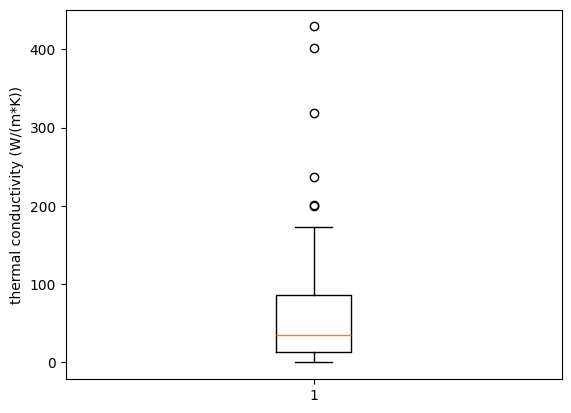

6 dots beyond the whiskers: [np.float64(200.0), np.float64(201.0), np.float64(237.0), np.float64(318.0), np.float64(401.0), np.float64(429.0)]


In [13]:
box = plt.boxplot(tc.dropna())
plt.ylabel('thermal conductivity (W/(m*K))')
plt.show()
fliers = sorted(box['fliers'][0].get_ydata())
print(f'{len(fliers)} dots beyond the whiskers: {fliers}')

The box spans Q1 to Q3, the whiskers reach out to the fence, and the 6 dots beyond them are
exactly the 6 elements the IQR rule just flagged in code -- `plt.boxplot` (your first appearance
of this tool) draws the same rule you already computed by hand, nothing more.

# Residual plots: outliers relative to a model

A second visual tool, tied directly back to the fitting you already know (Lecture 19-20): a
**residual plot**. Fit `melting_point` against `atomic_weight` with `np.polyfit` (the same tool
from Lecture 19), then plot the leftover error (`actual - predicted`) against `atomic_weight`.

In [14]:
aw = data['atomic_weight']
mask = mp.notna()
slope, intercept = np.polyfit(aw[mask], mp[mask], 1)
pred = slope * aw[mask] + intercept
resid = mp[mask] - pred
print(f'R^2 of this fit: {1 - np.var(resid) / np.var(mp[mask]):.3f}')

R^2 of this fit: 0.033


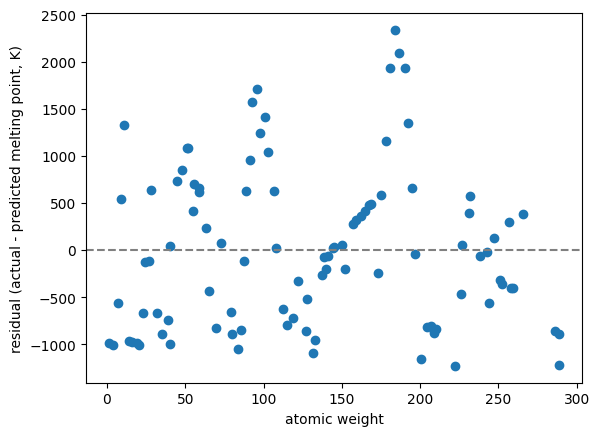

In [15]:
plt.scatter(aw[mask], resid)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('atomic weight')
plt.ylabel('residual (actual - predicted melting point, K)')
plt.show()

R² ≈ 0.03 -- atomic weight barely predicts melting point at all, and that's fine; this fit exists
only as a vehicle for computing residuals, not as a claim about a good model. Flag the outliers in
the residuals the same way as any other column, with a z-score on `resid`:

In [16]:
resid_z = (resid - resid.mean()) / resid.std()
flagged_resid = data.loc[mask][resid_z.abs() > 2]
print(f'{len(flagged_resid)} residual outliers (|resid z| > 2): {flagged_resid["symbol"].tolist()}')

5 residual outliers (|resid z| > 2): ['Mo', 'Ta', 'W', 'Re', 'Os']


Molybdenum, Tantalum, Tungsten, Rhenium, and Osmium -- refractory metals that melt far *higher*
than their atomic weight alone would predict. None were flagged as marginal outliers in Section 2
(their raw melting points, while high, weren't extreme enough alone); they only stand out once you
account for the trend line. This is the key upgrade over Sections 2-3: an outlier is sometimes
only visible *relative to a model*, not to the raw column. Mercury shows the same idea from the
other direction: its raw melting-point z-score is an unremarkable -1.18, but relative to its heavy
atomic weight it sits at resid z ≈ -1.36 -- notably further out, because a room-temperature liquid
metal is exactly what a naive "heavier atoms melt hotter" trend gets wrong.

# The judgment call: remove, keep, or flag?

This is the conceptual heart of the lecture, and it ties directly to Homework 9. Three categories,
each with a worked example from today's data.

**1. Legitimate extreme value.** Copper, silver, and gold's thermal conductivities were flagged by
*both* rules in Section 3 -- and they are real physics (the best electrical/thermal conductors
among common metals), not errors. Removing them because "they're far from the mean" would be
*data-doctoring*: discarding true, informative data because it's inconvenient for a
tighter-looking distribution.

**2. Data entry / parsing artifact.** `pd.to_numeric(data['melting_point'], errors='coerce')`
turned 5 more rows to `NaN` than were actually blank in the raw file:

In [17]:
raw_blank = data['melting_point'].isna().sum()
parse_fail = (data['melting_point'].notna() & mp.isna()).sum()
print(f'{raw_blank} rows were blank in the raw CSV; {parse_fail} more failed to parse')
data.loc[data['melting_point'].notna() & mp.isna(), ['name', 'symbol', 'melting_point']]

12 rows were blank in the raw CSV; 5 more failed to parse


,name,symbol,melting_point
86,Francium,Fr,"? 300 K (30 °C, 80 °F)"
92,Neptunium,Np,"912±3 K (639±3 °C, 1182±5 °F)"
96,Berkelium,Bk,"beta: 1259 K (986 °C, 1807 °F)"
114,Ununhexium,Uuh,"637780 K (364507 °C, 687944 °F) (extrapolated)"
115,Ununseptium,Uus,"623823 K (350550 °C, 6621022 °F) (predicted)"


Francium's value is `"? 300 K (30 degC, 80 degF)"`, Neptunium carries a `±` uncertainty, Berkelium
is prefixed `"beta:"`, and the two superheavy elements are marked `"(extrapolated)"` /
`"(predicted)"`. This is legitimately droppable or fixable -- it's not physics, it's a formatting
problem, and `errors='coerce'` already handled it correctly by turning it into a `NaN` rather than
a wrong number.

**3. Genuine ambiguous case.** Go back to Section 2's histogram: the low-temperature gas elements
form a visibly separate clump, even though neither rule formally flagged them here. That's worth
sitting with -- it cuts both ways. Section 3 showed a rule flagging real physics as suspicious
(Cu, Ag, Au); this is the mirror case, a rule *failing* to flag a real, different sub-population
(gases are a different phase of matter, not noise) because a threshold alone didn't catch it.
Removing the gas rows would change what your model can say about "elements" in general; keeping
them means admitting a single distribution doesn't describe the whole periodic table. Right
answer: don't just delete it -- segment or caveat instead.

One more "legitimate extreme value," from outside today's main dataset. Ceramics fail from their
single worst flaw, not their average flaw: brittle fracture strength is **weakest-link** physics,
so it follows a Weibull distribution with a fat low tail rather than a normal one. In a batch of 20
glass bars (mean 92.8 MPa), the weakest bar failed at 46.6 MPa -- about half the batch mean, z ≈
-2.03, real suspicion under the z-score rule above. But it must **not** be removed: it's a real
specimen that broke at its worst flaw, and a Weibull modulus (Homework 9) exists to *quantify* that
spread, not delete it. Fracture strength is a distribution, not a number with noise around it.

Close with a simple decision checklist, in words, not code:
* Can you explain a physical or procedural reason the point is unusual?
* Does removing it change the question you're allowed to ask afterward?
* Would you be comfortable defending the removal, in one sentence, in a report?

Name the anti-pattern explicitly: never remove a point *just because* it improves R² or makes a
fit "look better." That's p-hacking's cousin, and it's exactly what Homework 9 asks you to catch
yourself doing.

## [Check your understanding]

Run both rules on `electrical_resistivity` (coerce it with `pd.to_numeric` first, same as
`melting_point`): how many elements does the z-score rule flag? How many does the IQR fence flag?
Name the element(s) in each set, and write one sentence on whether you'd call each a legitimate
extreme value, a parsing artifact, or something else.

# Wrap-up

| Tool | What it catches | When to reach for it |
|---|---|---|
| z-score (\|z\|>3) | points far from the mean in std-dev units | roughly normal, unimodal columns |
| IQR fence | points outside `Q1-1.5*IQR` to `Q3+1.5*IQR` | more sensitive at the tails; robust to skew |
| `plt.boxplot` | the IQR fence, as a picture | quick visual scan of one column |
| residual plot | points far from a fitted *trend*, not just far from a mean | outliers only visible relative to a model |

None of these four makes the decision for you -- Problem 3 of Homework 9 will ask you to write
2-3 sentences justifying whatever you did with a flagged point.

**Take-home message:** a flagged point is a question, not an answer -- "unusual" and "wrong" are
different claims, and telling them apart is a judgment call you have to make and defend, not one
a threshold makes for you.

Next class: hypothesis testing -- "is this difference real, or could it be chance?" -- the same
move as today's outlier tests, generalized from one point to a comparison between two whole
groups.